# Day 9 · 회전 표현: 오일러 각도와 짐벌락


| Part | 주제 |
|------|------|
| Part 1 | 오일러 각도의 원리와 3D 회전 |
| Part 2 | 오일러 각도의 한계 — 짐벌락과 보간 문제 |

```
pip install ipywidgets ipympl plotly
pip install "nbformat>=4.2.0"
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, FloatSlider
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
# 3D 플롯을 마우스로 회전·확대할 수 있도록 interactive 백엔드 설정
# (VS Code Interactive 창이나 Jupyter에서 실행 시 적용됩니다)
%matplotlib widget

RuntimeError: 'widget is not a recognised GUI loop or backend name

In [ ]:
# 공통으로 사용할 회전 행렬 함수들
def rot_x(theta):
    """X축 회전 행렬 (roll)"""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[1, 0, 0],
                     [0, c, -s],
                     [0, s, c]])


def rot_y(theta):
    """Y축 회전 행렬 (pitch)"""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, 0, s],
                     [0, 1, 0],
                     [-s, 0, c]])


def rot_z(theta):
    """Z축 회전 행렬 (yaw)"""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s, 0],
                     [s, c, 0],
                     [0, 0, 1]])

In [ ]:
def euler_to_rotation_matrix(roll, pitch, yaw, order='ZYX'):
    """
    오일러 각도 → 회전 행렬
    로봇 공학에서 가장 흔한 순서: Z-Y-X (yaw → pitch → roll)
    """
    R_x = rot_x(roll)
    R_y = rot_y(pitch)
    R_z = rot_z(yaw)
    axis_map = {'X': R_x, 'Y': R_y, 'Z': R_z}

    # order 문자열을 거꾸로 읽어 행렬을 곱합니다.
    # 예: 'ZYX' -> R_z @ R_y @ R_x
    R = np.eye(3)
    for axis in reversed(order):
        R = axis_map[axis] @ R
    return R

In [ ]:
def draw_axes_3d(ax, R, origin=(0, 0, 0), scale=1.0,
                 colors=('r', 'g', 'b'), labels=None,
                 alpha=1.0, linewidth=2):
    """
    주어진 회전 행렬 R에 따라 3D 좌표축을 그립니다.
    R: 3x3 회전 행렬
    origin: 좌표축의 원점
    colors: (X축 색, Y축 색, Z축 색)
    """
    axes_vec = np.eye(3) * scale
    origin = np.array(origin)
    for i, (axis, color) in enumerate(zip(axes_vec, colors)):
        rotated = R @ axis
        ax.plot([origin[0], origin[0] + rotated[0]],
                [origin[1], origin[1] + rotated[1]],
                [origin[2], origin[2] + rotated[2]],
                color=color, linewidth=linewidth, alpha=alpha)
        if labels:
            ax.text(origin[0] + rotated[0] * 1.15,
                    origin[1] + rotated[1] * 1.15,
                    origin[2] + rotated[2] * 1.15,
                    labels[i], color=color, fontsize=10, fontweight='bold')

In [ ]:
def set_3d_axis_equal(ax, limit=1.5):
    """3D 축의 스케일을 동일하게 맞춥니다."""
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_zlim([-limit, limit])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

In [ ]:
# ───────────────────────────────────────────────
# Plotly 3D 시각화 공통 헬퍼 함수
# ───────────────────────────────────────────────
def _add_plotly_axes(fig, R=None, scale=1.0, row=None, col=None,
                     names=None, colors=None, line_width=3):
    """Plotly Figure에 3D 좌표축을 추가합니다."""
    axes = np.eye(3) * scale
    if names is None:
        names = ["X", "Y", "Z"]
    if colors is None:
        colors = ["#888888", "#888888", "#888888"]

    kwargs = {}
    if row is not None:
        kwargs['row'] = row
    if col is not None:
        kwargs['col'] = col

    for axis, name, color in zip(axes, names, colors):
        vec = R @ axis if R is not None else axis
        fig.add_trace(go.Scatter3d(
            x=[0, vec[0]], y=[0, vec[1]], z=[0, vec[2]],
            mode="lines+text",
            line=dict(color=color, width=line_width),
            text=["", name],
            textposition="top center",
            showlegend=False
        ), **kwargs)


def _plotly_scene(limit=1.5, eye=None):
    """Plotly 3D scene 공통 레이아웃을 반환합니다."""
    scene = dict(
        xaxis=dict(range=[-limit, limit], title="X", gridcolor="lightgray"),
        yaxis=dict(range=[-limit, limit], title="Y", gridcolor="lightgray"),
        zaxis=dict(range=[-limit, limit], title="Z", gridcolor="lightgray"),
        aspectmode="cube",
    )
    if eye is not None:
        scene["camera"] = dict(eye=eye)
    return scene


def plot_rotation_trajectory(rotations, title, n_arrows=6):
    """
    여러 회전 행렬의 궤적을 3D로 시각화합니다.
    rotations: (n_steps, 3, 3) 회전 행렬 리스트
    """
    fig = go.Figure()
    
    # 원래 좌표계 (World)
    _add_plotly_axes(fig, scale=1.2,
                     names=["X", "Y", "Z"],
                     colors=["#444444", "#444444", "#444444"],
                     line_width=3)
    
    n_steps = len(rotations)
    
    # 각 축(X', Y', Z')의 궤적 (끝점들을 선으로 연결)
    axis_colors = ["#e74c3c", "#2ecc71", "#3498db"]
    axis_names = ["X'", "Y'", "Z'"]
    
    for axis_idx in range(3):
        points = np.array([R[:, axis_idx] for R in rotations])
        fig.add_trace(go.Scatter3d(
            x=points[:, 0], y=points[:, 1], z=points[:, 2],
            mode='lines',
            line=dict(color=axis_colors[axis_idx], width=5),
            name=f"{axis_names[axis_idx]} trajectory",
            showlegend=True
        ))
        
        # 궤적 위의 주요 지점 마커
        step = max(1, n_steps // 10)
        fig.add_trace(go.Scatter3d(
            x=points[::step, 0],
            y=points[::step, 1],
            z=points[::step, 2],
            mode='markers',
            marker=dict(color=axis_colors[axis_idx], size=4, opacity=0.5),
            showlegend=False
        ))
    
    # 주요 단계의 좌표계 표시 (t=0, 중간, t=1)
    display_indices = [0, n_steps//4, n_steps//2, 3*n_steps//4, n_steps-1]
    for idx in display_indices:
        R = rotations[idx]
        t = idx / (n_steps - 1)
        alpha = 0.4 + 0.6 * t
        lw = 2 + 4 * t
        _add_plotly_axes(fig, R=R, scale=1.0,
                         names=[f"X'", f"Y'", f"Z'"],
                         colors=[
                             f"rgba(231,76,60,{alpha})",
                             f"rgba(46,204,113,{alpha})",
                             f"rgba(52,152,219,{alpha})"
                         ],
                         line_width=lw)
    
    fig.update_layout(
        title=dict(text=title, x=0.5),
        scene=_plotly_scene(1.5),
        width=700,
        height=650,
        margin=dict(l=0, r=0, b=0, t=40),
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
    )
    return fig


def make_dual_rotation_figure(R_left, R_right, title_left, title_right,
                              limit=1.5, width=1000, height=500):
    """두 회전 행렬을 나란히 비교하는 Plotly Figure를 생성합니다."""
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "scene"}, {"type": "scene"}]],
        subplot_titles=(title_left, title_right)
    )

    _add_plotly_axes(fig, row=1, col=1)
    _add_plotly_axes(fig, R=R_left, row=1, col=1,
                     names=["X'", "Y'", "Z'"],
                     colors=["#e74c3c", "#2ecc71", "#3498db"],
                     line_width=5)

    _add_plotly_axes(fig, row=1, col=2)
    _add_plotly_axes(fig, R=R_right, row=1, col=2,
                     names=["X'", "Y'", "Z'"],
                     colors=["#e74c3c", "#2ecc71", "#3498db"],
                     line_width=5)

    scene = _plotly_scene(limit, eye=dict(x=1.5, y=1.5, z=1.0))
    fig.update_layout(
        scene=scene, scene2=scene,
        width=width, height=height,
        margin=dict(l=0, r=0, b=0, t=40)
    )
    return fig

In [ ]:
# ───────────────────────────────────────────────
# 2D 회전 시각화 함수
# ───────────────────────────────────────────────
def plot_2d_rotation(point, angle_deg):
    """2D 평면에서 점을 회전시키고 시각화합니다."""
    angle_rad = np.deg2rad(angle_deg)
    R_2d = np.array([[np.cos(angle_rad), -np.sin(angle_rad)],
                     [np.sin(angle_rad),  np.cos(angle_rad)]])
    point_rotated = R_2d @ point

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot([0, point[0]], [0, point[1]], 'b-o', linewidth=2, label='Original')
    ax.plot([0, point_rotated[0]], [0, point_rotated[1]], 'r-s',
            linewidth=2, label=f'Rotated {angle_deg}°')
    ax.plot(0, 0, 'ko')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.legend()
    ax.set_title('2D Rotation')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"원래 점:     {point}")
    print(f"회전된 점:   {point_rotated}")
    return point_rotated

In [ ]:
# ───────────────────────────────────────────────
# 오일러 각도 보간 출력 함수
# ───────────────────────────────────────────────
def print_interpolation_steps(title, roll, pitch, yaw_angles_rad):
    """주어진 Yaw 각도 배열에 대해 회전 행렬을 출력합니다."""
    print(f"=== {title} ===\n")
    for yaw_rad in yaw_angles_rad:
        yaw_deg = np.rad2deg(yaw_rad)
        R = euler_to_rotation_matrix(roll, pitch, yaw_rad)
        print(f"Yaw = {yaw_deg:6.1f}°")
        with np.printoptions(precision=3, suppress=True):
            print(R)
        print()

---
## Part 1: 오일러 각도의 원리와 3D 회전

3D 공간에서 물체의 자세(orientation)를 표현하는 가장 직관적인 방법입니다.

### 1.1 오일러 각도란?

**오일러 각도(Euler Angles)** 는 3D 공간에서 물체의 회전을
**3개의 축에 대한 회전 각도** 로 표현합니다.

| 기호 | 이름 | 축 | 의미 (로봇 기준) |
|------|------|----|----------------|
| **φ (phi)** | Roll | X축 | 전후 롤링 (앞뒤 기울기) |
| **θ (theta)** | Pitch | Y축 | 상하 피칭 (고개 숙임) |
| **ψ (psi)** | Yaw | Z축 | 좌우 요우 (방향 전환) |

> **핵심 직관**: "비행기 조종사 관점"
> - **Roll**: 날개를 좌우로 기울임 (롤)
> - **Pitch**: 기수를 위아래로 듦/내림 (피치)
> - **Yaw**: 수평면에서 좌우로 방향 전환 (요)

In [ ]:
# 오일러 각도 예시 (단위: 도)
roll_deg = 30    # X축 회전
pitch_deg = 20   # Y축 회전
yaw_deg = 45     # Z축 회전

# NumPy 삼각함수는 라디안을 사용합니다.
roll_rad = np.deg2rad(roll_deg)
pitch_rad = np.deg2rad(pitch_deg)
yaw_rad = np.deg2rad(yaw_deg)

print(f"Roll  (X축): {roll_deg}° = {roll_rad:.4f} rad")
print(f"Pitch (Y축): {pitch_deg}° = {pitch_rad:.4f} rad")
print(f"Yaw   (Z축): {yaw_deg}° = {yaw_rad:.4f} rad")

Roll  (X축): 30° = 0.5236 rad
Pitch (Y축): 20° = 0.3491 rad
Yaw   (Z축): 45° = 0.7854 rad


### 1.2 2D 회전부터 이해하기

3D보다 간단한 **2D 평면 회전** 을 먼저 이해하면 오일러 각도가 쉬워집니다.

2D 공간에서 점 $(x, y)$를 원점 기준으로 $\theta$만큼 회전시키면:

$$
x' = x \cos\theta - y \sin\theta \\
y' = x \sin\theta + y \cos\theta
$$

이를 행렬로 쓰면:
$$
\begin{bmatrix} x' \\ y' \end{bmatrix}
=
\begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}
\begin{bmatrix} x \\ y \end{bmatrix}
$$

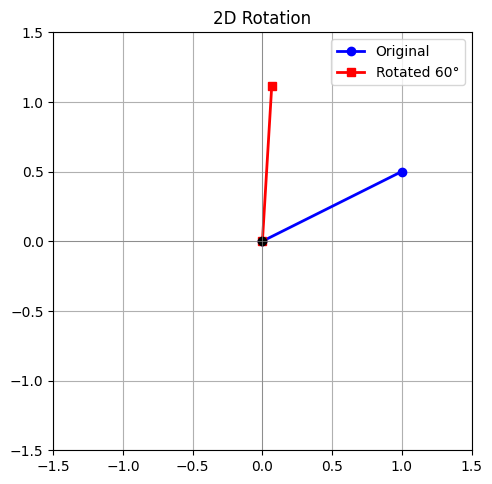

원래 점:     [1.  0.5]
회전된 점:   [0.0669873 1.1160254]


array([0.0669873, 1.1160254])

In [22]:
# 2D 회전 시각화
point = np.array([1.0, 0.5])
angle_deg = 60

plot_2d_rotation(point, angle_deg)

### 1.3 3D 회전 행렬

2D와 마찬가지로, 3D 공간에서도 각 축별 회전을 **행렬**로 표현합니다.

**X축 회전 (Roll)** — YZ 평면이 회전합니다:
$$
R_x(\phi) = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
$$

**Y축 회전 (Pitch)** — XZ 평면이 회전합니다:
$$
R_y(\theta) = \begin{bmatrix}
\cos\theta & 0 & \sin\theta \\
0 & 1 & 0 \\
-\sin\theta & 0 & \cos\theta
\end{bmatrix}
$$

**Z축 회전 (Yaw)** — XY 평면이 회전합니다:
$$ R_z(\psi) = \begin{bmatrix}
\cos\psi & -\sin\psi & 0 \\
\sin\psi & \cos\psi & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

In [24]:
# 각 축별 회전 행렬 확인
phi = np.deg2rad(30)   # roll
theta = np.deg2rad(20) # pitch
psi = np.deg2rad(45)   # yaw

print("=== X축 회전 행렬 (Roll) ===")
print(np.round(rot_x(phi), 4))
print("\n=== Y축 회전 행렬 (Pitch) ===")
print(np.round(rot_y(theta), 4))
print("\n=== Z축 회전 행렬 (Yaw) ===")
print(np.round(rot_z(psi), 4))

=== X축 회전 행렬 (Roll) ===
[[ 1.     0.     0.   ]
 [ 0.     0.866 -0.5  ]
 [ 0.     0.5    0.866]]

=== Y축 회전 행렬 (Pitch) ===
[[ 0.9397  0.      0.342 ]
 [ 0.      1.      0.    ]
 [-0.342   0.      0.9397]]

=== Z축 회전 행렬 (Yaw) ===
[[ 0.7071 -0.7071  0.    ]
 [ 0.7071  0.7071  0.    ]
 [ 0.      0.      1.    ]]


### 1.4 3D 공간에서 오일러 각도 회전 시각화

아래 그림에서 **검은 축**은 원래 좌표계(World),
**색깔 축**은 오일러 각도로 회전한 새로운 좌표계(Body)입니다.

In [ ]:
# 오일러 각도 (Z-Y-X 순서)로 3D 회전 시각화
roll = np.deg2rad(30)
pitch = np.deg2rad(20)
yaw = np.deg2rad(45)

# Z-Y-X 순서로 회전 행렬 계산
R = euler_to_rotation_matrix(roll, pitch, yaw)
R

array([[ 0.66446302, -0.49145005,  0.5629971 ],
       [ 0.66446302,  0.73329482, -0.14410968],
       [-0.34202014,  0.46984631,  0.81379768]])

In [ ]:
# Interactive 3D 회전 시각화 — 슬라이더로 각도를 조절할 수 있습니다 (Plotly)
@interact(
    roll_deg=FloatSlider(min=-180, max=180, step=5, value=30, description='Roll (°)'),
    pitch_deg=FloatSlider(min=-180, max=180, step=5, value=20, description='Pitch (°)'),
    yaw_deg=FloatSlider(min=-180, max=180, step=5, value=45, description='Yaw (°)')
)
def plot_interactive_euler(roll_deg=30, pitch_deg=20, yaw_deg=45):
    R = euler_to_rotation_matrix(
        np.deg2rad(roll_deg), np.deg2rad(pitch_deg), np.deg2rad(yaw_deg)
    )

    fig = go.Figure()
    _add_plotly_axes(fig, scale=1.0,
                     names=["X", "Y", "Z"],
                     colors=["#444444", "#444444", "#444444"])
    _add_plotly_axes(fig, R=R, scale=1.0,
                     names=["X'", "Y'", "Z'"],
                     colors=["#e74c3c", "#2ecc71", "#3498db"],
                     line_width=5)

    fig.update_layout(
        title=dict(
            text=f'Euler Angles (ZYX) — Roll={roll_deg:.0f}°, Pitch={pitch_deg:.0f}°, Yaw={yaw_deg:.0f}°',
            x=0.5
        ),
        scene=_plotly_scene(1.5),
        width=700,
        height=650,
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

### 1.5 회전 순서의 중요성

오일러 각도는 **회전 순서**에 따라 결과가 달라집니다.
로봇 공학에서는 보통 **Z-Y-X** 순서를 사용합니다.

> 왜 순서가 중요할까요?
>
> 행렬 곱셈은 **교환법칙이 성립하지 않습니다** ($AB \neq BA$).
> 즉, X축 먼저 돌리고 Z축을 돌리는 것과,
> Z축 먼저 돌리고 X축을 돌리는 것은 **완전히 다른 결과**를 냅니다.

In [ ]:
# 회전 순서 비교: ZYX vs XZY — Plotly 3D 시각화
roll = np.deg2rad(30)
pitch = np.deg2rad(20)
yaw = np.deg2rad(45)

R_zyx = rot_z(yaw) @ rot_y(pitch) @ rot_x(roll)   # 일반적인 순서
R_xzy = rot_x(roll) @ rot_z(yaw) @ rot_y(pitch)   # 다른 순서

fig = make_dual_rotation_figure(
    R_zyx, R_xzy,
    "Order: Z → Y → X (ZYX) — Standard in Robotics",
    "Order: X → Z → Y (XZY) — Different Result!"
)
fig.show()

print("같은 각도(30, 20, 45)라도 순서가 다르면 전혀 다른 방향을 가리킵니다.")

---
## Part 2: 오일러 각도의 한계 — 짐벌락과 보간 문제

오일러 각도는 직관적이지만, 실제 로봇·게임 개발에서 치명적인 약점이 있습니다.

### 2.1 짐벌락(Gimbal Lock)이란?

**짐벌락**은 3D 회전에서 두 개의 회전 축이 **같은 평면에 겹쳐져**,
원래 3개였던 자유도(독립적인 회전 방향)가 **2개로 줄어드는** 현상입니다.

> **비유**: 카메라 짐벌을 생각해보세요.
> 피칭(Pitch)을 90°(수직 위쪽)으로 들면,
> 롤(Roll)과 요우(Yaw)가 같은 방향의 회전이 되어버립니다.
> 이때 '머리를 갸우뚱거리는' 롤과 '몸을 돌리는' 요우를 **구분할 수 없게 됩니다**.

수학적으로는 Z-Y-X 순서에서 **Pitch = ±90°** 일 때 발생합니다:
$$
R_y(90°) \text{ 를 적용하면 } X \text{축과 } Z \text{축이 같은 평면에 놓입니다.}
$$

### 2.2 짐벌락의 핵심 증명

Pitch = 90°일 때, Z-Y-X 회전 행렬을 전개하면:

$$
Z(\psi) \cdot Y(90°) \cdot X(\phi) =
\begin{bmatrix}
0 & \sin(\phi-\psi) & \cos(\phi-\psi) \\
0 & \cos(\phi-\psi) & -\sin(\phi-\psi) \\
-1 & 0 & 0
\end{bmatrix}
$$

즉, Roll(φ)와 Yaw(ψ)가 **같은 Z축 회전**으로 합쳐집니다.
결과는 **φ − ψ (Roll − Yaw)의 차이**로만 결정되므로,
원래 3개의 독립적인 회전이었는데 **2개만 남게** 됩니다.

In [ ]:
# Pitch = 90°에서 Roll − Yaw의 차이가 같으면 결과가 같은지 확인
pitch_90 = np.deg2rad(90)

# 경우 A: Roll=30°, Yaw=0°  →  Roll − Yaw = 30°
R_A = euler_to_rotation_matrix(np.deg2rad(30), pitch_90, np.deg2rad(0))
# 경우 B: Roll=0°, Yaw=−30°  →  Roll − Yaw = 30° (Case A와 동일)
R_B = euler_to_rotation_matrix(np.deg2rad(0), pitch_90, np.deg2rad(-30))
print("R_A:")
print(np.round(R_A, 4))
print("\nR_B:")
print(np.round(R_B, 4))

In [ ]:
fig = make_dual_rotation_figure(
    R_A, R_B,
    "Case A: Roll=30°, Pitch=90°, Yaw=0°",
    "Case B: Roll=0°, Pitch=90°, Yaw=−30°"
)
fig.show()

print("두 경우의 결과가 동일합니다 → Roll과 Yaw를 독립적으로 구분할 수 없음!")
print("이것이 바로 짐벌락(Gimbal Lock)입니다.")

### 2.3 짐벌락 직접 확인하기 (인터랙티브)

아래 슬라이더로 **Roll**, **Pitch**, **Yaw**를 직접 조절해 보세요.  
특히 **Pitch = 90°**일 때, **Roll − Yaw** 값이 같으면 **완전히 동일한 자세**가 됨을 3D 화면에서 직접 확인할 수 있습니다.

In [ ]:
def create_interactive_gimbal():
    """슬라이더로 오일러 각도를 조절하며 짐벌락을 직접 확인하는 인터랙티브 3D 화면"""
    from ipywidgets import Output, VBox

    output = Output()

    def draw(roll_deg, pitch_deg, yaw_deg):
        R = euler_to_rotation_matrix(
            np.deg2rad(roll_deg), np.deg2rad(pitch_deg), np.deg2rad(yaw_deg)
        )

        fig = go.Figure()
        _add_plotly_axes(fig)
        _add_plotly_axes(fig, R=R,
                         names=["X'", "Y'", "Z'"],
                         colors=["#e74c3c", "#2ecc71", "#3498db"],
                         line_width=5)

        diff = roll_deg - yaw_deg
        fig.update_layout(
            title=dict(
                text=f"Roll={roll_deg:.1f}°, Pitch={pitch_deg:.1f}°, Yaw={yaw_deg:.1f}°  |  Roll−Yaw = {diff:.1f}°"
            ),
            scene=_plotly_scene(1.5, eye=dict(x=1.5, y=1.5, z=1.0)),
            width=700,
            height=650,
            margin=dict(l=0, r=0, b=0, t=50)
        )

        with output:
            output.clear_output(wait=True)
            fig.show()

    interact(
        draw,
        roll_deg=FloatSlider(min=-180, max=180, step=5, value=30,
                             description="Roll (°)", layout=dict(width='95%')),
        pitch_deg=FloatSlider(min=-180, max=180, step=5, value=90,
                              description="Pitch (°)", layout=dict(width='95%')),
        yaw_deg=FloatSlider(min=-180, max=180, step=5, value=0,
                            description="Yaw (°)", layout=dict(width='95%'))
    )

    return output


interactive_gimbal = create_interactive_gimbal()
interactive_gimbal

### 2.4 오일러 각도의 보간(Interpolation) 문제

로봇이 **자세 A에서 자세 B로 부드럽게 이동**해야 할 때,
오일러 각도를 직접 선형 보간하면 **이상한 경로**를 타게 됩니다.

**오일러 각도 직접 보간의 문제:** (0°, 0°, 0°) → (30°, 60°, 90°)

오일러 각도를 직접 선형 보간하면, 회전 공간에서 최단 경로를 따르지 않습니다.
아래 출력과 3D 궤적을 확인해 보세요.

In [ ]:
n_steps = 50
roll_deg  = np.linspace(0, 150, n_steps)
pitch_deg = np.linspace(0, 60, n_steps)
yaw_deg   = np.linspace(0, 120, n_steps)

print("=== Euler Direct Interpolation: (0°, 0°, 0°) → (150°, 60°, 120°) ===\n")
rotations_euler = []
for i in range(n_steps):
    t = i / (n_steps - 1)
    R = euler_to_rotation_matrix(
        np.deg2rad(roll_deg[i]),
        np.deg2rad(pitch_deg[i]),
        np.deg2rad(yaw_deg[i])
    )
    rotations_euler.append(R)
    if i % 5 == 0:
        print(f"t = {t:.1f}  (Roll={roll_deg[i]:6.1f}°, Pitch={pitch_deg[i]:6.1f}°, Yaw={yaw_deg[i]:6.1f}°)")
        with np.printoptions(precision=3, suppress=True):
            print(R)
        print()

print("오일러 각도를 직접 선형 보간하면, 회전 공간에서 최단 경로를 따르지 않습니다.\n")

In [ ]:
# 오일러 각도 직접 보간의 3D 궤적 시각화
fig = plot_rotation_trajectory(
    rotations_euler,
    title="Euler Direct Interpolation<br><sub>(0°, 0°, 0°) → (150°, 60°, 120°)</sub>"
)
fig.show()